In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

In [2]:
IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

In [3]:
df_tracks = pd.read_csv("tracks.csv")

print("Dataset shape:", df_tracks.shape)
df_tracks.head()

Dataset shape: (586672, 20)


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [4]:
df_tracks['release_date'] = pd.to_datetime(
    df_tracks['release_date'],
    format='mixed',
    errors='coerce'
)

if "duration" not in df_tracks.columns:
    if "duration_ms" in df_tracks.columns:
        df_tracks["duration"] = (df_tracks["duration_ms"] / 1000).round()

In [5]:
numeric_df = df_tracks.select_dtypes(include='number')

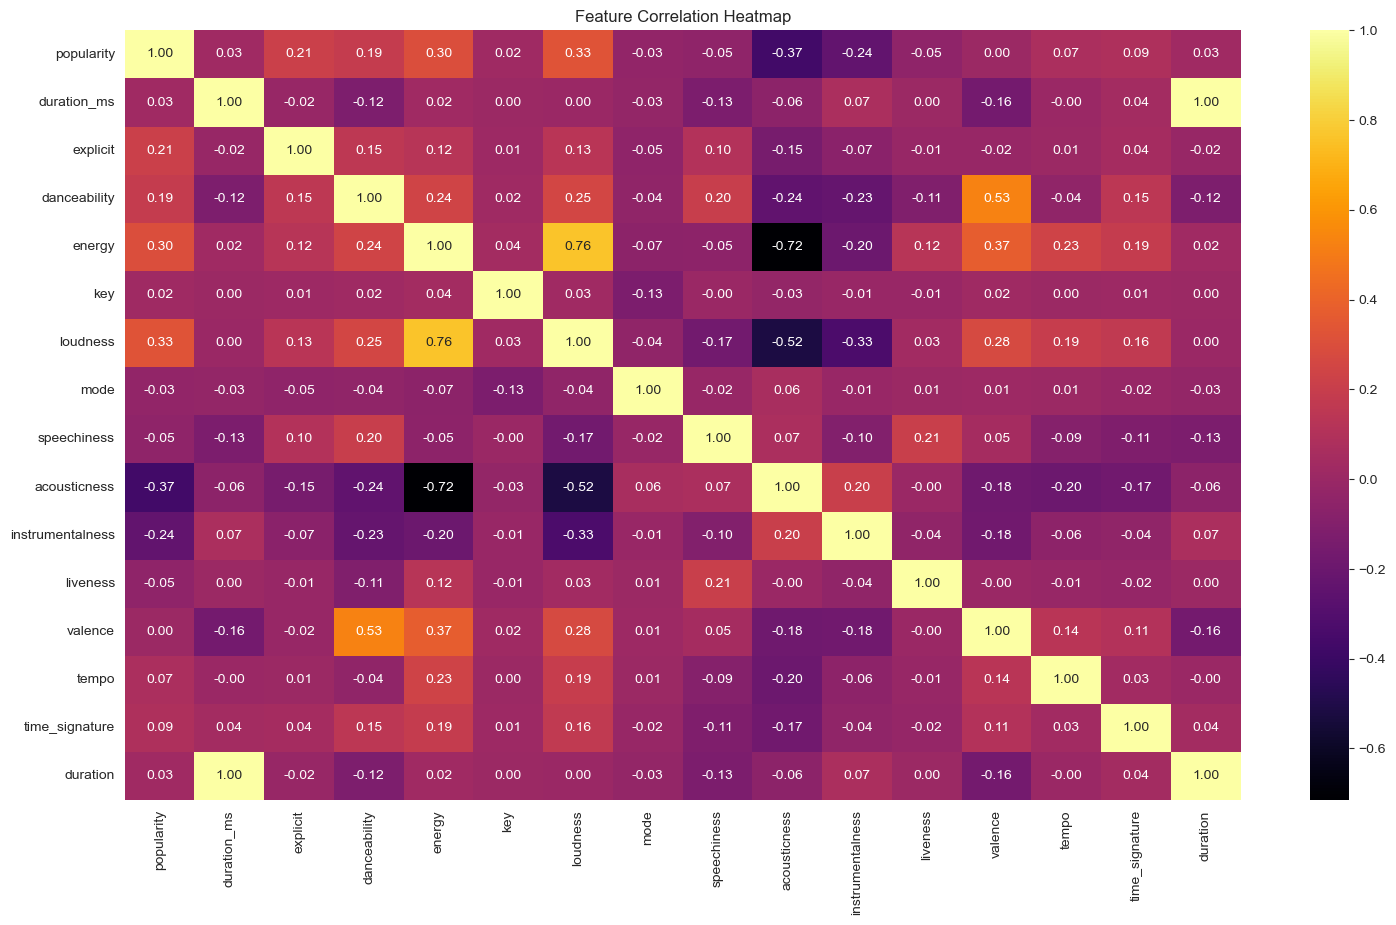

In [6]:
corr_df = numeric_df.corr()

plt.figure(figsize=(18, 10))
sns.heatmap(corr_df, annot=True, cmap="inferno", fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.savefig(f"{IMAGE_DIR}/heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
sample_size = max(1, int(0.004 * len(df_tracks)))
sample_df = df_tracks.sample(sample_size, random_state=42)

In [26]:
print(f"Sample size used for analysis: {sample_size}")

Sample size used for analysis: 2346


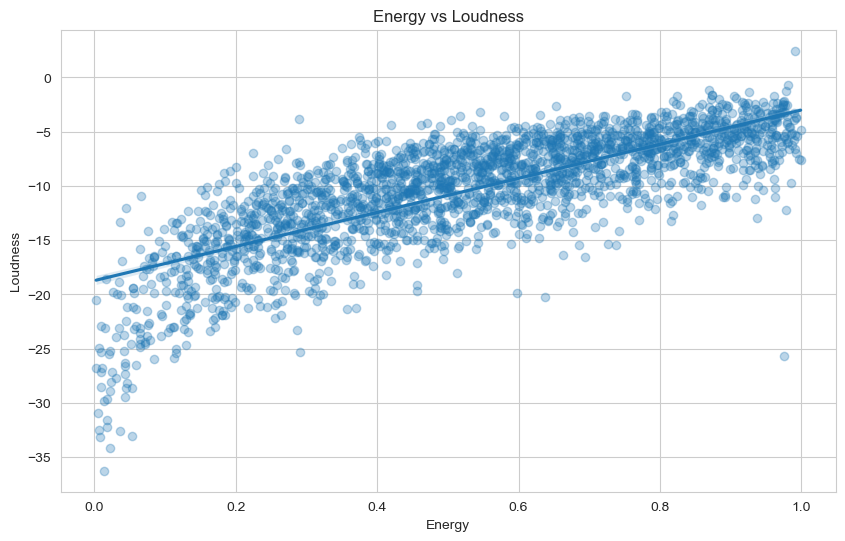

In [22]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=sample_df,
    x="energy",
    y="loudness",
    scatter_kws={"alpha": 0.3}
)

plt.title("Energy vs Loudness")
plt.xlabel("Energy")
plt.ylabel("Loudness")

plt.savefig(f"{IMAGE_DIR}/energy_loudness.png", dpi=300, bbox_inches='tight')
plt.show()

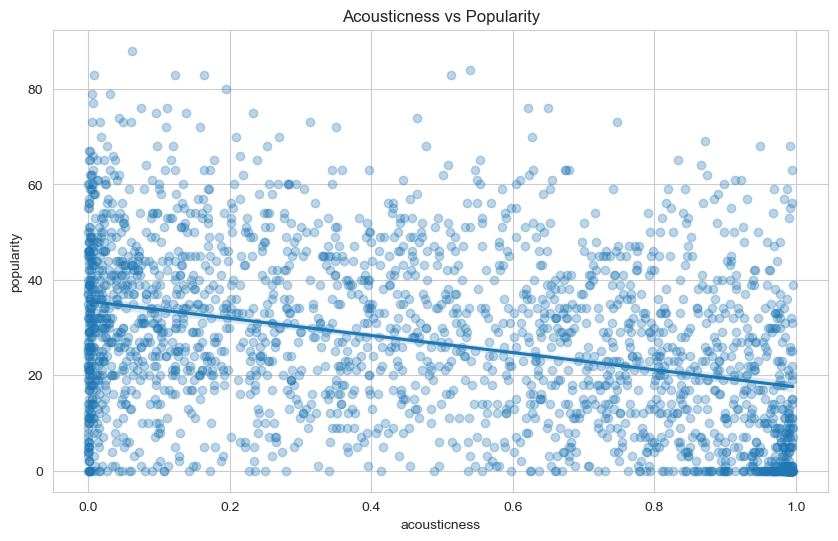

In [9]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=sample_df,
    x="acousticness",
    y="popularity",
    scatter_kws={"alpha": 0.3}
)

plt.title("Acousticness vs Popularity")

plt.savefig(f"{IMAGE_DIR}/acoustic_popularity.png", dpi=300, bbox_inches='tight')
plt.show()

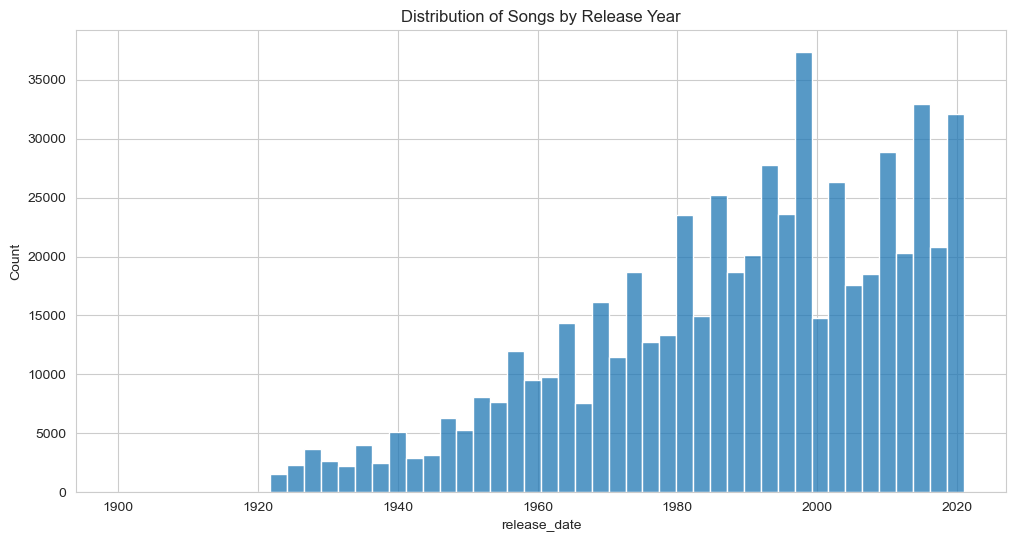

In [10]:
years = df_tracks['release_date'].dt.year.dropna()

plt.figure(figsize=(12, 6))

sns.histplot(years, bins=50)

plt.title("Distribution of Songs by Release Year")

plt.savefig(f"{IMAGE_DIR}/year_distribution.png", dpi=300, bbox_inches='tight')
plt.show()